## AM115 Group Project - Sensitivity Analysis

## SEIRD Model
- states: Susceptible, Infected, Exposed, Dead, Recovered

## Parameters Research
- sensitivity of optimal sharpness for different alpha
- sensitivity of optimal sharpness for different pt

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [29]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"
# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.titlesize"] = 20

- unit of time will be in days
- we fix the lockdown start time to 7. It didn't make sense to vary this because the optimization will always choose the earliest time to start a lockdown.
- we vary sharpness and min number of contacts, these represent the speed and strength of the lockdown
- it doesn't make much logical sense that one would wait to start if they know patient zero is infected.

In [30]:
def nc_func(t, sharpness, min_val=1, max_val=6, lockdown_start=7):
    """
    Calculate contact rate nc with exponential decay after lockdown_start.

    Args:
        t: Current time
        sharpness: Negative value controlling decay speed (more negative = faster lockdown)
        min_val: Minimum contact rate (lockdown strength)
        max_val: Maximum contact rate (normal activity)
        lockdown_start: Fixed time when lockdown begins (default=5)

    Returns:
        Contact rate between min_val and max_val
    """
    t0 = max(t - lockdown_start, 0)  # Time since lockdown started
    decay = np.exp(sharpness * t0)  # Exponential decay factor
    return min_val + (max_val - min_val) * decay  # Always between min_val and max_val

$$
a(t) = pt \cdot nc(t)
$$
$$
nc(t) = (nc_{max} - 1) \cdot e^{t_{start} * s}
$$

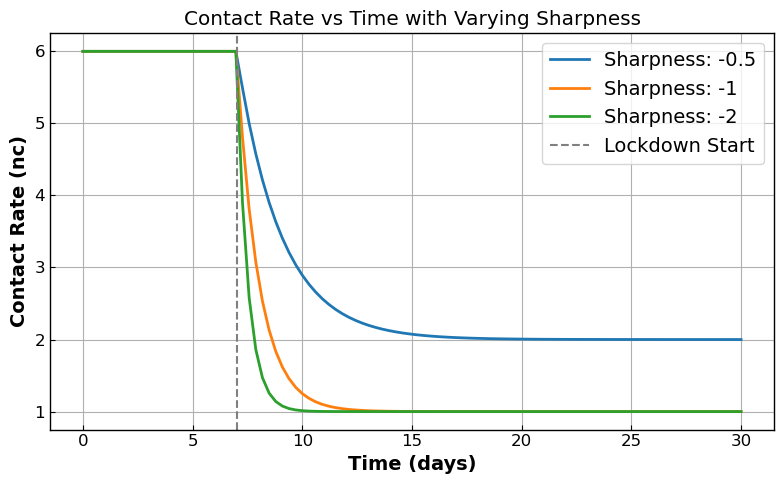

In [31]:
ts = np.linspace(0, 30, 100)

plt.figure(figsize=(8, 5))
for sharpness in [-0.5, -1, -2]:
    min_val = 1
    if sharpness > -1:
        min_val = 2  # Increase minimum value for sharper lockdowns
    ncs = [nc_func(ti, sharpness, min_val) for ti in ts]

    plt.plot(ts, ncs, label=f"Sharpness: {sharpness}", linewidth=2)
plt.xlabel("Time (days)")
plt.ylabel("Contact Rate (nc)")
plt.title("Contact Rate vs Time with Varying Sharpness")
plt.axvline(x=7, color="gray", linestyle="--", label="Lockdown Start")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("./plots/lockdown_function.png")
plt.show()

In [32]:
def lockdown_intensity(t, sharpness, nc_min, nc_max=6):
    """Normalizes the contact rate nc to a value between 0 and 1.
    This is done via min-max scaling.
    """
    nc = nc_func(t, sharpness, nc_min, nc_max)
    return (nc_max - nc) / (nc_max - nc_min)

In [33]:
def economic_cost(t, alpha, sharpness, min_val):
    # alpha is the weight for economic cost
    # alpha = 1 means human life is 10m
    # alpha = 0.5 means human life is 5m
    # lockdown intensity is the fraction of GDP lost
    return lockdown_intensity(t, sharpness, min_val)

In [34]:
def simulate_seird(sharpness, min_val, t_span, y0, pt, b, c, eta, gamma, nu, N):
    def rhs(t, X):
        nc = nc_func(t, sharpness, min_val)
        a = pt * nc
        s, e, i, r, d = X
        ds = -a * s * i / N - c * s + gamma * r
        de = a * s * i / N - nu * e
        di = nu * e - b * i - eta * i
        dr = b * i + c * s - gamma * r
        dd = eta * i
        return [ds, de, di, dr, dd]

    sol = solve_ivp(rhs, t_span, y0, t_eval=np.linspace(t_span[0], t_span[1], 400))
    return sol

In [35]:
# Revised Constants (MUST ADJUST THESE TO YOUR SCENARIO)
# units are in millions

GDP_PER_DAY = 750  # this is 1 billion per day
VALUE_OF_LIFE = 15  # this is 15 million per life
HOSP_COST_PER_DAY = 0.015  # this is $15,000 per day per person in hospital


def total_cost(
    params,
    t_span,
    y0,
    pt,
    b,
    c,
    eta,
    gamma,
    nu,
    N,
    hospital_capacity,
    GDP_PER_DAY,
    VALUE_OF_LIFE,
):
    sharpness, min_val = params

    # Run simulation
    sol = simulate_seird(sharpness, min_val, t_span, y0, pt, b, c, eta, gamma, nu, N)
    t = sol.t
    # days = t[-1] - t[0]  # Total simulation duration

    # 1. Death Cost (in $M)
    death_cost = sol.y[4][-1] * VALUE_OF_LIFE

    # 2. Economic Cost (in $M)
    # First get average lockdown intensity
    # avg_lockdown = np.mean([lockdown_intensity(ti, sharpness, min_val) for ti in t])
    # econ_cost = avg_lockdown * GDP_PER_DAY * days

    # 2. Economic Cost ($M) - INTEGRATED properly
    lockdown_values = [lockdown_intensity(ti, sharpness, min_val) for ti in t]
    econ_cost = np.trapz(lockdown_values, t) * GDP_PER_DAY  # ∫(intensity) dt * GDP

    # 3. Hospital Penalty (in $M)
    # y is SEIRD, so y[2] is the number of infected
    excess_hosp = np.maximum(sol.y[2] - hospital_capacity, 0)
    hosp_penalty = np.trapz(excess_hosp, t) * HOSP_COST_PER_DAY

    return death_cost + econ_cost + hosp_penalty

- The paper finds the range of cost to be 10 - 13k. We use 15k just to be on the conservative side.

Source
- https://pmc.ncbi.nlm.nih.gov/articles/PMC10765267/

### Parameters

In [36]:
# Parameters
# Time span for simulation is 120 days or
# roughly 4 months
tspan = (0, 120)
t_eval = np.arange(0, 120, 0.1)

In [37]:
# Population size
N = 2e6

In [38]:
# nc ranges from 6 to 1
# vary this to match the R0
pt = 0.1

- The probability of transmission for covid takes on a wide range depending on the environment and length of exposure. For household transmission $pt$ can be as high as 0.189.
- In contrast for outdoor transmission it can be as low as less than 0.01.

Sources
- https://pubmed.ncbi.nlm.nih.gov/35482308/
- https://academic.oup.com/jid/article/223/4/550/6009483

In [39]:
# research found ranges from 0.03 to 0.06
b = 0.05

- From the below sources, we found a suitable range for $b$ the recovery rate.
- The range we establish is from 0.03 to 0.06. For our analysis we will use 0.05, since it is around the midpoint of the range.

Sources
- https://jamanetwork.com/journals/jamanetworkopen/fullarticle/2820087
- https://www.thelancet.com/journals/lanwpc/article/PIIS2666-6065(21)00117-6/fulltext
- https://www.tandfonline.com/doi/full/10.1080/25765299.2022.2148439#d1e7295

In [40]:
# The vacinnation rate from 2020-2021 was around 0.013
VAX_RATE = 0.69  # per year
c = VAX_RATE / (365)
c

0.0018904109589041095

- To establish a vaccination rate, we use data from the source linked below.
- We took the percent vaccinated at Dec 2020 which was 0% and at Dec 2021 which was 69%.
- To get vaccinations per day we divide the 69% by 365 days to get a daily rate of 0.002.

Sources
- https://ourworldindata.org/covid-vaccinations

In [41]:
# the death rate from infected was 0.008 but we round
eta = 0.01 * b / (1 - 0.01)
eta

0.000505050505050505

- The death rate given in the source below which is around 1% on average.

$$
CFR = \frac{\eta}{\eta + b}
$$
- Using this we can solve for $\eta$ given $b$ and the CFR (1%).

Source
- https://ourworldindata.org/mortality-risk-covid

In [42]:
gamma = 0.008

- a new wave appears every 4 months or 120 days
- $\gamma = \frac{1}{120} = 0.00833$

Sources
- https://www.nature.com/articles/s41579-023-00878-2
- https://link.springer.com/article/10.1186/s12982-024-00140-x

In [43]:
nu = 0.22

- The sources describe the latent period as 4-5 days, so we use 0.22 as the rate.

Sources- https://pmc.ncbi.nlm.nih.gov/articles/PMC9837419/?utm_source=chatgpt.com

In [44]:
# Patient 0 scenario
X0 = [N - 1, 1, 0, 0, 0]

In [45]:
# Parameters
# Time span for simulation is 120 days or
# roughly 4 months
tspan = (0, 120)
t_eval = np.arange(0, 120, 0.1)
# Population size
N = 2e6
# nc ranges from 6 to 1
# vary this to match the R0
pt = 0.1
# research found ranges from 0.03 to 0.06
b = 0.05
# The vacinnation rate from 2020-2021 was around 0.013
VAX_RATE = 0.69  # per year
c = VAX_RATE / (365)
# the death rate from infected was 0.008 but we round
DEATH_RATE = 0.01
eta = DEATH_RATE * b / (1 - DEATH_RATE)
gamma = 0.008
nu = 0.22
# Patient 0 scenario
X0 = [N - 1, 1, 0, 0, 0]

# Hospital capacity is 0.3% of the population
hospital_capacity = N * 0.003

- The total number of beds in 913136 per 1000 people in the US.
- The total population of the US is 334 million.
- 913136 / 334,000 = 2.74 beds per 1000 people
- Or 0.00274 beds per person. That's how we arrive at N * 0.003 for hospital capacity.


Source
- https://www.aha.org/statistics/fast-facts-us-hospitals



In [46]:
from scipy.optimize import minimize

# Bounds:
# sharpness ∈ [-1, -0.01] (negative, more negative = faster lockdown)
# min_val ∈ [1, 4] (reasonable range for lockdown strength)
bounds = [(-2, -0.001), (1, 4)]

# Initial guess
initial_guess = [-0.02, 3]  # [sharpness, min_val]

# Fixed parameters
args = (
    tspan,
    X0,
    pt,
    b,
    c,
    eta,
    gamma,
    nu,
    N,
    hospital_capacity,
    GDP_PER_DAY,
    VALUE_OF_LIFE,
)

# Run optimization
res = minimize(
    total_cost,
    initial_guess,
    args=args,
    method="L-BFGS-B",
    bounds=bounds,
    options={"disp": True, "ftol": 1e-8, "maxiter": 1000},  # Smaller = more precise
)

print(f"Optimal sharpness: {res.x[0]:.4f}, min_val: {res.x[1]:.4f}")
print(f"Minimum cost: {res.fun:.2f}")

Optimal sharpness: -0.0489, min_val: 1.0000
Minimum cost: 71695.07


- $\alpha = 0.5$ implies \$5M of economic impact is valued equivalently to 1 life lost (since $\alpha$ = 0.5 means the model treats 0.5 units of economic cost = 1 death).
- we use 1 unit of economic cost = 1 death as a baseline for our model.
- Let a life be worth \$10M, then $\alpha = 0.1$ implies \$1M of economic impact is valued equivalently to 1 life lost (since $\alpha$ = 0.1 means the model treats 0.1 units of economic cost = 1 death).

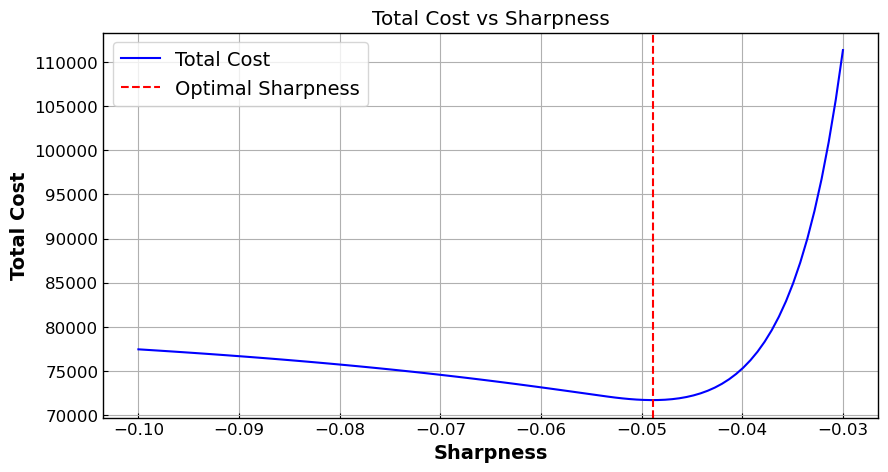

In [47]:
# plot total cost as a function of sharpness
sharpness_values = np.linspace(-2, -0.001, 100)
sharpness_values = np.linspace(-0.1, -0.03, 100)
min_val_fixed = res.x[1]
total_costs = [
    total_cost(
        [sharpness, min_val_fixed],
        tspan,
        X0,
        pt,
        b,
        c,
        eta,
        gamma,
        nu,
        N,
        hospital_capacity,
        GDP_PER_DAY,
        VALUE_OF_LIFE,
    )
    for sharpness in sharpness_values
]


plt.figure(figsize=(10, 5))
plt.plot(sharpness_values, total_costs, label="Total Cost", color="blue")
plt.axvline(res.x[0], color="red", linestyle="--", label="Optimal Sharpness")
plt.xlabel("Sharpness")
plt.ylabel("Total Cost")
plt.title("Total Cost vs Sharpness")
plt.legend()
plt.grid()
plt.savefig("./plots/optimum.png")
plt.show()

In [48]:
# Parameters
# Time span for simulation is 120 days or
# roughly 4 months
tspan = (0, 120)
t_eval = np.arange(0, 120, 0.1)
# Population size
N = 2e6
# nc ranges from 6 to 1
# vary this to match the R0
pt = 0.1
# research found ranges from 0.03 to 0.06
b = 0.05
# The vacinnation rate from 2020-2021 was around 0.013
VAX_RATE = 0.69  # per year
c = VAX_RATE / (365)
# the death rate from infected was 0.008 but we round
DEATH_RATE = 0.01
eta = DEATH_RATE * b / (1 - DEATH_RATE)
gamma = 0.008
nu = 0.22
# Patient 0 scenario
X0 = [N - 1, 1, 0, 0, 0]

$$
\text{GDP per capita} = \text{GDP PER DAY} * 365 / N
$$

In [49]:
gdp_values = np.logspace(np.log10(50), np.log10(1000), 50)
# GDP per capita in millions
gdp_values * 365 / N

array([0.009125  , 0.00970029, 0.01031184, 0.01096195, 0.01165304,
       0.01238771, 0.01316869, 0.01399891, 0.01488147, 0.01581968,
       0.01681703, 0.01787725, 0.01900433, 0.02020245, 0.02147612,
       0.02283008, 0.0242694 , 0.02579946, 0.02742599, 0.02915506,
       0.03099314, 0.0329471 , 0.03502425, 0.03723235, 0.03957966,
       0.04207496, 0.04472757, 0.04754742, 0.05054504, 0.05373165,
       0.05711917, 0.06072024, 0.06454835, 0.06861779, 0.0729438 ,
       0.07754254, 0.0824312 , 0.08762808, 0.09315258, 0.09902539,
       0.10526844, 0.11190508, 0.11896013, 0.12645997, 0.13443263,
       0.14290793, 0.15191756, 0.16149519, 0.17167665, 0.1825    ])

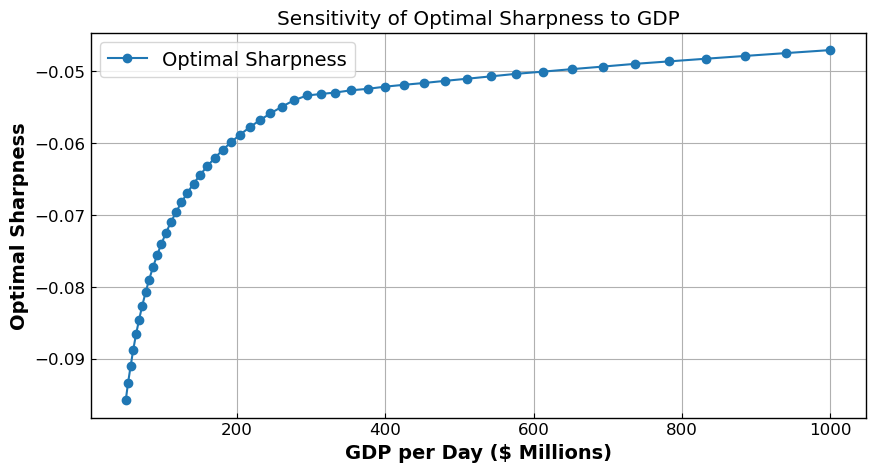

In [50]:
# sensitivity of optimal sharpness for GDP
gdp_values = np.logspace(np.log10(50), np.log10(1000), 50)
optimal_sharpness = []
for gdp in gdp_values:
    args = (
        tspan,
        X0,
        pt,
        b,
        c,
        eta,
        gamma,
        nu,
        N,
        hospital_capacity,
        gdp,
        VALUE_OF_LIFE,
    )
    res = minimize(
        total_cost,
        initial_guess,
        args=args,
        method="L-BFGS-B",
        bounds=bounds,
        options={"disp": True},
    )
    optimal_sharpness.append(res.x[0])

plt.figure(figsize=(10, 5))
plt.plot(gdp_values, optimal_sharpness, marker="o", label="Optimal Sharpness")
plt.xlabel("GDP per Day ($ Millions)")
plt.ylabel("Optimal Sharpness")
plt.title("Sensitivity of Optimal Sharpness to GDP")
plt.grid()
plt.legend()
plt.savefig("./plots/gdp_sensitivity.png")
plt.show()

- probability of transmission varies depending on environment 0.01 to 0.2

In [51]:
# Parameters
# Time span for simulation is 120 days or
# roughly 4 months
tspan = (0, 120)
t_eval = np.arange(0, 120, 0.1)
# Population size
N = 2e6
# nc ranges from 6 to 1
# vary this to match the R0
pt = 0.1
# research found ranges from 0.03 to 0.06
b = 0.05
# The vacinnation rate from 2020-2021 was around 0.013
VAX_RATE = 0.69  # per year
c = VAX_RATE / (365)
# the death rate from infected was 0.008 but we round
DEATH_RATE = 0.01
eta = DEATH_RATE * b / (1 - DEATH_RATE)
gamma = 0.008
nu = 0.22
# Patient 0 scenario
X0 = [N - 1, 1, 0, 0, 0]

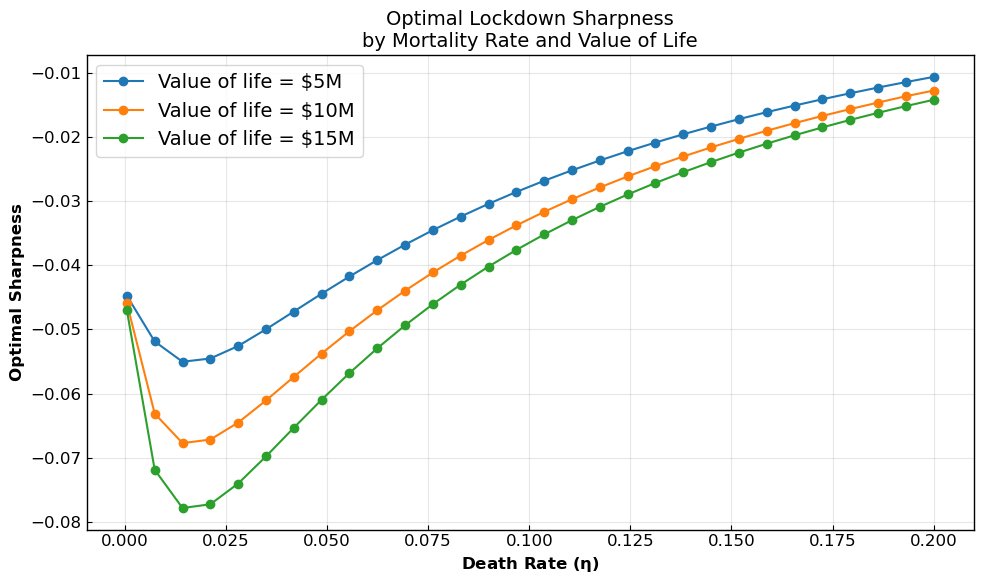

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Setup
eta_values = np.linspace(0.0005, 0.2, 30)
val_life_list = [5, 10, 15]  # Different values of life in millions
GDP_PER_DAY = 1000
plt.figure(figsize=(10, 6))

# Color palette for distinct lines
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for val_life, color in zip(val_life_list, colors):
    optimal_sharpness_eta = np.zeros(len(eta_values))

    for i, eta in enumerate(eta_values):
        res = minimize(
            total_cost,
            initial_guess,
            args=(
                tspan,
                X0,
                pt,
                b,
                c,
                eta,
                gamma,
                nu,
                N,
                hospital_capacity,
                GDP_PER_DAY,
                val_life,
            ),
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "gtol": 1e-8,
                "maxiter": 1000,
                "finite_diff_rel_step": 1e-5,
            },
        )
        optimal_sharpness_eta[i] = res.x[0]

    # Plot all lines on same figure
    plt.plot(
        eta_values,
        optimal_sharpness_eta,
        marker="o",
        linestyle="-",
        color=color,
        label=f"Value of life = ${val_life}M",
    )

# Formatting
plt.xlabel("Death Rate ($\\eta$)", fontsize=12)
plt.ylabel("Optimal Sharpness", fontsize=12)
plt.title(
    "Optimal Lockdown Sharpness\nby Mortality Rate and Value of Life",
    fontsize=14,
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("./plots/death_sensitivity.png")
plt.show()

In [53]:
# Parameters
# Time span for simulation is 120 days or
# roughly 4 months
tspan = (0, 120)
t_eval = np.arange(0, 120, 0.1)
# Population size
N = 2e6
# nc ranges from 6 to 1
# vary this to match the R0
pt = 0.1
# research found ranges from 0.03 to 0.06
b = 0.05
# The vacinnation rate from 2020-2021 was around 0.013
VAX_RATE = 0.69  # per year
c = VAX_RATE / (365)
# the death rate from infected was 0.008 but we round
DEATH_RATE = 0.01
eta = DEATH_RATE * b / (1 - DEATH_RATE)
gamma = 0.008
nu = 0.22
# Patient 0 scenario
X0 = [N - 1, 1, 0, 0, 0]

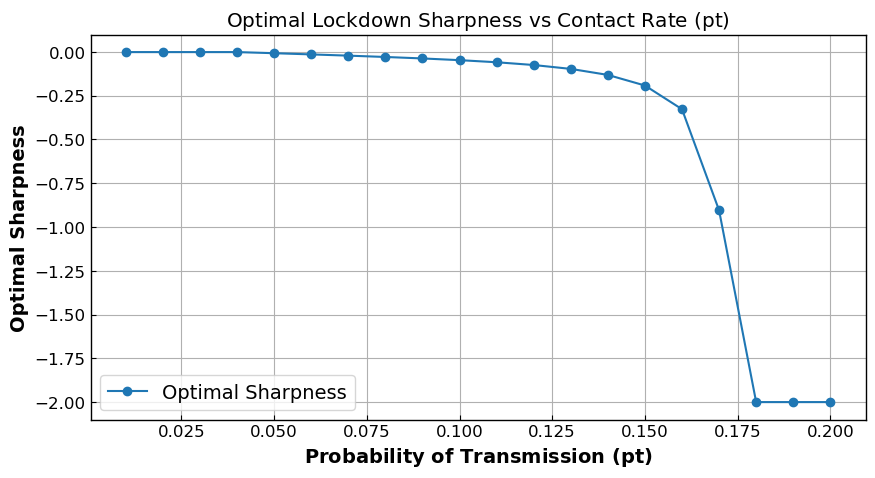

In [54]:
# sensitivity of optimal sharpness for different pt
from scipy.optimize import basinhopping


num_candidates = 20
optimal_sharpness_pt = np.zeros(num_candidates)
pts = np.linspace(0.01, 0.2, num_candidates)
GDP_PER_DAY = 1000
for i, pt in enumerate(pts):
    res = basinhopping(
        lambda x: total_cost(
            x,
            tspan,
            X0,
            pt,
            b,
            c,
            eta,
            gamma,
            nu,
            N,
            hospital_capacity,
            GDP_PER_DAY,
            VALUE_OF_LIFE=VALUE_OF_LIFE,
        ),
        initial_guess,
        minimizer_kwargs={"method": "L-BFGS-B", "bounds": bounds},
        niter=10,
        stepsize=0.1,
    )
    optimal_sharpness_pt[i] = res.x[0]
plt.figure(figsize=(10, 5))
plt.plot(pts, optimal_sharpness_pt, marker="o", label="Optimal Sharpness")
plt.xlabel("Probability of Transmission ($pt$)")
plt.ylabel("Optimal Sharpness")
plt.title("Optimal Lockdown Sharpness vs Contact Rate ($pt$)")
plt.grid()
plt.legend()
plt.savefig("./plots/pt_sensitivity.png")
plt.show()